<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/Posterior_Normality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Asymptotic Posterior Normality (Bernstein–von Mises)

10-29-2025

Derivation of posterior's asymptotic distribution, following Prof. Jasmine Foo's (UMN) notes. Simulation to compare to MLE asymptotics.

---

Let $X_1,\dots,X_n$ be i.i.d. from a parametric family with density $f(x\mid\theta)$, true parameter $\theta_0\in\Theta\subset\mathbb R^d$, and prior $\pi(\theta)$ that is positive and continuously differentiable near $\theta_0$.

The posterior density is
$$
\pi_n(\theta) =
\frac{\exp\{\ell_n(\theta)\}\pi(\theta)}{\int_\Theta \exp\{\ell_n(u)\}\pi(u)\,du},
\qquad
\ell_n(\theta) = \sum_{i=1}^n \log f(X_i\mid\theta).
$$



Assumptions:

1. $\hat\theta_n$ (MLE) exists and is consistent for $\theta_0$.  

2. $\ell(x,\theta)$ is twice continuously differentiable in a neighborhood of $\theta_0$, with $I(\theta_0)$ positive definite.  

3. $\pi(\theta)$ is continuous and positive near $\theta_0$.  

4. The model is identifiable and the likelihood admits a local quadratic expansion.

(1) Taylor expansion of the log-likelihood

Expand $\ell_n(\theta)$ around the MLE $\hat\theta_n$:

$$
\ell_n(\theta)
= \ell_n(\hat\theta_n)
+ \nabla\ell_n(\hat\theta_n)^{\!T}(\theta-\hat\theta_n)
-\tfrac12(\theta-\hat\theta_n)^\top J_n(\tilde\theta_n)(\theta-\hat\theta_n)
+ R_n(\theta;\hat\theta_n),
$$

where $J_n(\theta)=-\nabla_\theta^2\ell_n(\theta)$ is the observed information, $\tilde\theta_n$ lies between $\hat\theta_n$ and $\theta$, and the remainder

$$R_n(\theta;\hat\theta_n)=o_p(\|\theta-\hat\theta_n\|^2)$$

Since $\nabla\ell_n(\hat\theta_n)=0$, the linear term drops out, leaving

$$
\ell_n(\theta)
\approx
\ell_n(\hat\theta_n)
-\tfrac12(\theta-\hat\theta_n)^\top J_n(\tilde\theta_n)(\theta-\hat\theta_n).
$$

By continuity and consistency,

$$J_n(\tilde\theta_n)/n - J_n(\hat\theta_n)/n \xrightarrow{p} 0,$$  

and

$$
J_n(\hat\theta_n)/n \xrightarrow{p} I(\theta_0)$$ (the Fisher information).  Thus locally,

$$
\exp\{\ell_n(\theta)\}
\approx
\exp\{\ell_n(\hat\theta_n)\}
\exp\!\Big[-\tfrac{n}{2}(\theta-\hat\theta_n)^\top I(\theta_0)(\theta-\hat\theta_n)\Big].
$$

(2) Expand the log-prior

Near $\hat\theta_n$:

$$
\log\pi(\theta)
\approx
\log\pi(\hat\theta_n)
+ (\theta-\hat\theta_n)^\top\nabla\log\pi(\hat\theta_n)
-\tfrac12(\theta-\hat\theta_n)^\top\Lambda_0(\theta-\hat\theta_n),
$$

where $\Lambda_0=-\nabla^2\log\pi(\theta_0)$ is $O(1)$.  

Because the likelihood curvature grows as $O(n)$, the prior’s influence on the posterior shape vanishes as $n\to\infty$.

(3) Combine likelihood and prior

Multiplying the two expansions gives the unnormalized posterior:

$$
\pi_n(\theta)\propto
\exp\!\Big[
-\tfrac12(\theta-\hat\theta_n)^\top(J_n(\hat\theta_n)+\Lambda_0)(\theta-\hat\theta_n)
+(\theta-\hat\theta_n)^\top\nabla\log\pi(\hat\theta_n)
\Big].
$$

Completing the square, this is approximately multivariate normal with

$$
\bar\theta_n
= \hat\theta_n + (J_n(\hat\theta_n)+\Lambda_0)^{-1}\nabla\log\pi(\hat\theta_n),
\qquad
\Sigma_n = (J_n(\hat\theta_n)+\Lambda_0)^{-1}.
$$

(4) Large-sample limits

As $n\to\infty$,

$$
J_n(\hat\theta_n)=nI(\theta_0)+o_p(n), \qquad \Lambda_0=O(1),
$$

thus

$$
\Sigma_n = (nI(\theta_0))^{-1} + o_p(n^{-1}),
\qquad
\bar\theta_n - \hat\theta_n = O_p(n^{-1}).
$$

Hence the posterior mass concentrates around $\hat\theta_n$ with variance $O(1/n)$, and the difference between posterior mean and MLE vanishes at $O_p(1/n)$.

(5) Limit form (Bernstein–von Mises)

Uniformly for $h$ in compact sets,

$$
\pi_n(\hat\theta_n + h/\sqrt{n})
\approx
\phi\!\big(h; 0, I(\theta_0)^{-1}\big),
$$

where $\phi(\cdot;0,\Sigma)$ is the multivariate normal density. Equivalently, for $\theta\sim\pi_n(\cdot\mid X)$,

$$
\boxed{
\sqrt{n}\,I(\theta_0)^{1/2}\,(\theta-\hat\theta_n)
\ \xrightarrow{d}\
\mathcal N(0,I_d)
}
$$

(6) Notes:

- The likelihood curvature dominates the prior curvature as $n$ increases.  
- The posterior becomes approximately Gaussian around the MLE:
  $$
  \Pi(\theta\mid X_{1:n}) \approx \mathcal N\!\big(\hat\theta_n,(nI(\theta_0))^{-1}\big)
  $$
- Posterior mean, mode, and MLE coincide asymptotically.  
- The posterior covariance matches the inverse Fisher information scaled by $1/n$.  
- Thus Bayesian credible sets coincide (asymptotically) with frequentist confidence intervals.

---

Thus under mild regularity conditions, the posterior distribution is asymptotically normal with the same variance as the MLE:

$$
\Pi(\theta\mid X_{1:n})
\ \approx\
\mathcal N\!\big(\hat\theta_n,(nI(\theta_0))^{-1}\big).
$$


Demonstrate 3 key points: asymptotic normality, waning influence of prior on posterior precision as sample grows, and comparison to MLE. Utility functions and parameters first.

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt

# reproducible RNG
rng = np.random.default_rng(2025)


# normal density
def normal_pdf(x, mu=0.0, sigma=1.0):
    """
    Evaluate Normal(mu, sigma) pdf at x.

    Parameters:
    ----------
      x    : float or np.ndarray
             point(s) at which to evaluate pdf
      mu   : float
             mean of distribution
      sigma: float
             standard deviation of distribution

    Returns:
    ----------
      pdf  : float or np.ndarray
             value(s) of pdf at x
    """
    # variance
    var = sigma**2

    # standardized squared differences
    q = (x - mu) ** 2 / (2.0 * var)

    # normalization constant
    denom = np.sqrt(2.0 * np.pi * var)

    # pdf
    pdf = np.exp(-q) / denom
    return pdf


# laplace density
def laplace_pdf(x, mu, b):
    """
    Evaluate Laplace(mu, b) pdf at x.

    Parameters:
    ----------
      x  : float or np.ndarray
           evaluation points
      mu : float
           location
      b  : float
           scale (>0)

    Returns:
    ----------
      pdf: float or np.ndarray
           density values
    """
    # absolute deviation
    d = np.abs(x - mu)

    # pdf
    pdf = (0.5 / b) * np.exp(-d / b)
    return pdf


# posterior draws for normal-mean with known sigma using a grid prior
def posterior_draws_normal_mean_grid(x, sigma, theta_grid, prior_on_grid, M):
    """
    Draw posterior samples for Normal-mean with known sigma using a
    grid-evaluated prior.

    Parameters:
    ----------
      x            : np.ndarray
                     data vector (shape (n,))
      sigma        : float
                     known observation sd
      theta_grid   : np.ndarray
                     1-D grid of theta values
      prior_on_grid: np.ndarray
                     prior density evaluated at grid
      M            : int
                     number of posterior draws to return

    Returns:
    ----------
      draws        : np.ndarray
                     posterior samples (shape (M,))
    """
    # sample size and mean
    n = x.size
    xbar = x.mean()

    # likelihood kernel across the grid
    k = n / (2.0 * sigma**2)
    like = np.exp(-k * (theta_grid - xbar) ** 2)

    # unnormalized posterior on the grid
    unnorm = prior_on_grid * like

    # normalize to probabilities
    w = unnorm / unnorm.sum()

    # posterior draws
    draws = rng.choice(theta_grid, size=M, replace=True, p=w)
    return draws


# standardize posterior draws around MLE using sqrt(n * I_hat)
def standardize_draws(theta_draws, n, I_hat, theta_hat):
    """
    Standardize posterior draws using Z = sqrt(n I_hat) * (theta - theta_hat).

    Parameters:
    ----------
      theta_draws: np.ndarray
                   posterior samples (shape (M,))
      n          : int
                   sample size
      I_hat      : float
                   Fisher information per observation evaluated at theta_hat
      theta_hat  : float
                   MLE computed from the data

    Returns:
    ----------
      Z          : np.ndarray
                   standardized draws (shape (M,))
    """
    # scale factor
    sc = np.sqrt(n * I_hat)

    # standardized draws
    Z = sc * (theta_draws - theta_hat)
    return Z


# ----------------------------
# Set Parameters
# ----------------------------
# true mean and known sd
mu0, sigma = 0.75, 1.0

# sample sizes
n_list = [10, 50, 200, 1000]

# reps per n for histograms
R = 200

# posterior draws per replication
M_post = 200

# non-normal prior: bimodal Laplace mixture
w, mu1, b1, mu2, b2 = 0.5, -3.0, 0.5, 3.0, 0.5

# theta grid for prior/posterior discretization
theta_grid = np.linspace(-8.0, 8.0, 4001)

# prior density on grid
prior_on_grid = w * laplace_pdf(theta_grid, mu1, b1)
prior_on_grid += (1.0 - w) * laplace_pdf(theta_grid, mu2, b2)

# x-grid for N(0,1) overlay
x_plot = np.linspace(-4.0, 4.0, 2001)



## 1. Asymptotic Normality

Empirically demonstrate BvM theorem. Simulate Bayesian posteriors for a Normal‐mean model

$$
X_i \mid \theta \sim \mathcal N(\theta,\sigma^2)
$$

with a non-normal, bimodal Laplace-mixture prior on $\theta$. Draw posterior samples on a grid and standardize:

$$
Z = \sqrt{n I(\hat\theta)}\,(\theta-\hat\theta),
\qquad I(\theta)=1/\sigma^2
$$

Compare histograms of standardized posterior draws to $\mathcal N(0,1)$.

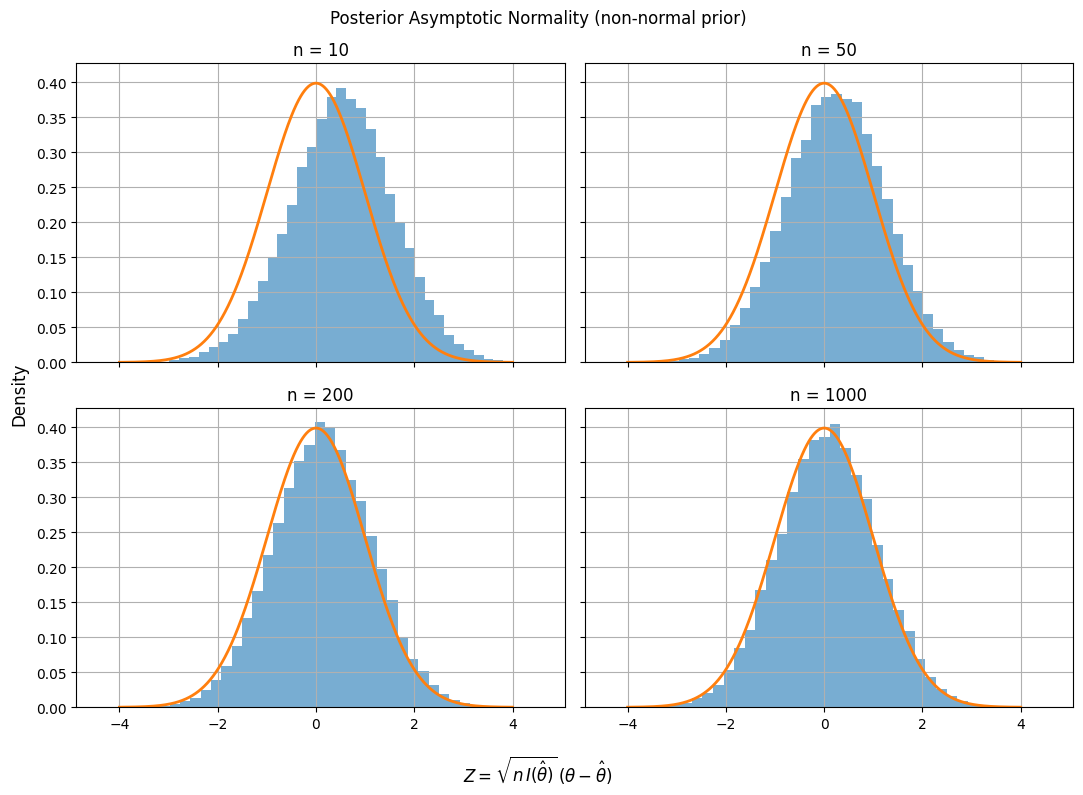

In [2]:

# create 2x2 subplots (one per n)
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
axs = axes.ravel()

# iterate over sample sizes
for i, n in enumerate(n_list):

    # pooled standardized draws for this n
    Z_all = []

    # R replications
    for r in range(R):

        # simulate data
        x = rng.normal(loc=mu0, scale=sigma, size=n)

        # MLE and per-observation Fisher information
        theta_hat = x.mean()
        I_hat = 1.0 / (sigma**2)

        # posterior draws under non-normal prior
        theta_draws = posterior_draws_normal_mean_grid(x, sigma, theta_grid, prior_on_grid, M_post)

        # standardized posterior draws
        Z = standardize_draws(theta_draws, n, I_hat, theta_hat)

        # collect draws
        Z_all.append(Z)

    # concatenate across replications
    Z_all = np.concatenate(Z_all, axis=0)

    # pick subplot
    ax = axs[i]

    # histogram of standardized posterior draws
    ax.hist(Z_all, bins=40, density=True, alpha=0.6)

    # standard normal overlay
    ax.plot(x_plot, normal_pdf(x_plot), linewidth=2.0)

    # cosmetics
    ax.set_title(f"n = {n}")
    ax.grid(True)

# shared labels and layout
fig.supxlabel(r"$Z = \sqrt{n\,I(\hat\theta)}\,(\theta - \hat\theta)$")
fig.supylabel("Density")
fig.suptitle("Posterior Asymptotic Normality (non-normal prior)", y=0.98)
plt.tight_layout()
plt.show()


As $n$ grows, the posterior is increasingly Gaussian and centered at $\hat\theta$. Even under a highly non-normal prior, the posterior approaches a normal shape as $n\to\infty$.

## 2. Prior Influence on Posterior Precision

Posterior precision (inverse variance) approaches the likelihood precision as $n$ increases. For each sample size $n$:

- Simulate data and draw from the posterior using the same non-normal prior

- Compute the posterior variance $\widehat{\text{Var}}(\theta\mid X)$

- Compare to the theoretical likelihood variance $\sigma^2/n$

Plot the ratio

$$
\text{Precision Ratio}
=
\frac{1/\widehat{\text{Var}}(\theta\mid X)}{1/(\sigma^2/n)}
$$

where each $n$ is a point on the scatter plot. Expect convergence to 1.


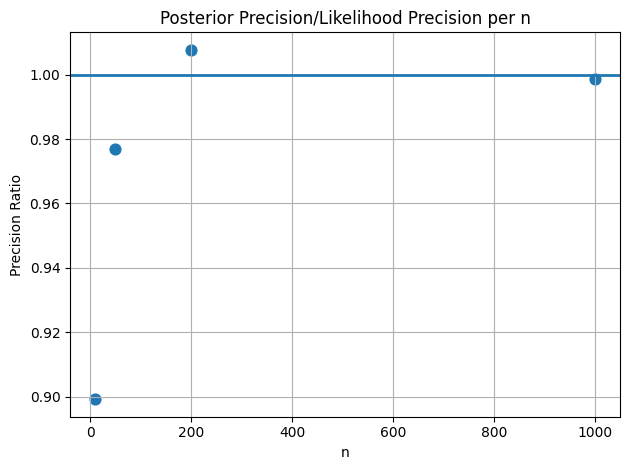

In [3]:
# containers for ratios
ratio_post_to_like = []

# loop over n and compute posterior variance via average over reps
for n in n_list:

    # collect posterior variances per replication
    post_var_rep = []

    # replications
    for r in range(150):

        # simulate data
        x = rng.normal(loc=mu0, scale=sigma, size=n)

        # posterior draws
        theta_draws = posterior_draws_normal_mean_grid(x, sigma, theta_grid,
                                                       prior_on_grid, M=200)

        # within rep posterior variance
        post_var_rep.append(np.var(theta_draws, ddof=1))

    # average posterior variance across reps
    post_var_mean = float(np.mean(post_var_rep))

    # likelihood/theory variance from Fisher info: Var(θ̂_MLE) = sigma^2 / n
    like_var = (sigma**2) / n

    # precision ratio: (1/post_var_mean)/(1/like_var)=like_var/post_var_mean
    ratio_post_to_like.append(like_var / post_var_mean)

# scatter, one point per n
fig = plt.figure()
plt.scatter(n_list, ratio_post_to_like, s=60)
plt.axhline(y=1.0, linewidth=2.0)
plt.title("Posterior Precision/Likelihood Precision per n")
plt.xlabel("n")
plt.ylabel("Precision Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Posterior and MLE Variances Converge

Compare three variance measures across $n$:

1. Theoretical variance from Fisher information:

   $$
   \text{Var}(\hat\theta) = \frac{\sigma^2}{n}
   $$

2. Posterior variance (empirical, averaged over simulations)

3. MLE variance (empirical, from repeated samples)

As $n$ increases, posterior and MLE variances match $\sigma^2/n$. For large $n$, posterior uncertainty and frequentist MLE sampling variability are asymptotically identical, confirming

$$
\Pi(\theta\mid X_{1:n}) \approx
\mathcal N\!\big(\hat\theta,(nI(\theta_0))^{-1}\big)
\quad\text{and}\quad
\sqrt{n}(\hat\theta-\theta_0)\!\xrightarrow{d}\!\mathcal N(0,I(\theta_0)^{-1})
$$


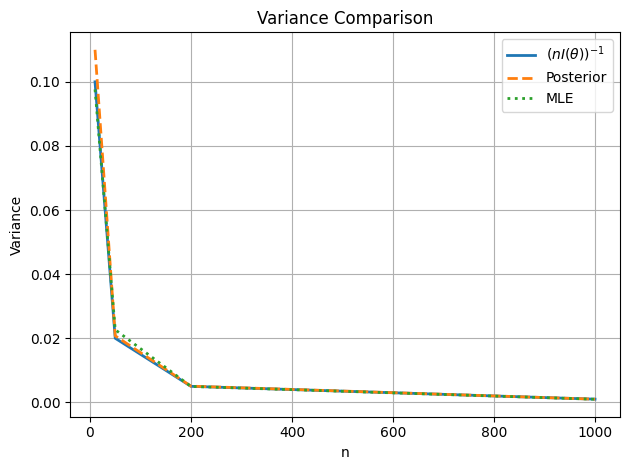

In [4]:
# containers
post_var = []
mle_var  = []
like_var = []

# loop over n
for n in n_list:

    # per-rep collections
    post_var_rep = []
    mu_hat_rep   = []

    # replications
    for r in range(120):

        # simulate data
        x = rng.normal(loc=mu0, scale=sigma, size=n)

        # MLE for mean
        mu_hat = x.mean()
        mu_hat_rep.append(mu_hat)

        # posterior draws
        theta_draws = posterior_draws_normal_mean_grid(x, sigma, theta_grid,
                                                       prior_on_grid, M=250)

        # posterior variance
        post_var_rep.append(np.var(theta_draws, ddof=1))

    # aggregate posterior variance (mean over reps)
    post_var.append(float(np.mean(post_var_rep)))

    # empirical MLE variance across reps
    mle_var.append(float(np.var(np.asarray(mu_hat_rep), ddof=1)))

    # theoretical variance from Fisher information
    like_var.append((sigma**2) / n)

# arrays for plotting
n_arr   = np.asarray(n_list)
post_var = np.asarray(post_var)
mle_var  = np.asarray(mle_var)
like_var = np.asarray(like_var)

# plot with three series
fig = plt.figure()

# theory: (n I)^(-1)
plt.plot(n_arr, like_var, linewidth=2.0, label=r"$(nI(\theta))^{-1}$")

# posterior variance (empirical)
plt.plot(n_arr, post_var, linewidth=2.0, linestyle="--", label="Posterior")

# MLE variance (empirical)
plt.plot(n_arr, mle_var,  linewidth=2.0, linestyle=":", label="MLE")

# title, label, grid
plt.title("Variance Comparison")
plt.xlabel("n")
plt.ylabel("Variance")
plt.grid(True)

# display
plt.legend()
plt.tight_layout()
plt.show()
